# Project — Chapter 82: Predator–Prey Model

> **Prerequisites:** ch076 (Discrete Dynamical Systems), ch078 (Simulation)
>
> **Concepts used:** 2D dynamical systems, cycles, bifurcations, ecological modeling
>
> **Output:** Lotka-Volterra simulation with phase portraits and bifurcation analysis
>
> **Difficulty:** Intermediate | ~45 minutes

---

## 0. Overview

This is a Project chapter. Each stage builds on the previous. Read the problem statement, then execute the stages in order.

---

## 1. Setup

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Lotka-Volterra parameters
alpha = 0.8   # prey birth rate
beta  = 0.05  # predation rate (prey lost per predator-prey encounter)
delta = 0.03  # predator growth per prey eaten
gamma = 0.4   # predator death rate

print("Lotka-Volterra Predator-Prey Model")
print("  dx/dt = αx - βxy  (prey: grow minus predation)")
print("  dy/dt = δxy - γy  (predator: gain from prey minus death)")
print(f"  α={alpha}, β={beta}, δ={delta}, γ={gamma}")
print(f"  Fixed point: x*={gamma/delta:.1f}, y*={alpha/beta:.1f}")

Lotka-Volterra Predator-Prey Model
  dx/dt = αx - βxy  (prey: grow minus predation)
  dy/dt = δxy - γy  (predator: gain from prey minus death)
  α=0.8, β=0.05, δ=0.03, γ=0.4
  Fixed point: x*=13.3, y*=16.0


---

## 2. Stage 1 — Continuous Simulation

Simulate the Lotka-Volterra ODEs using Euler integration and plot the time series.

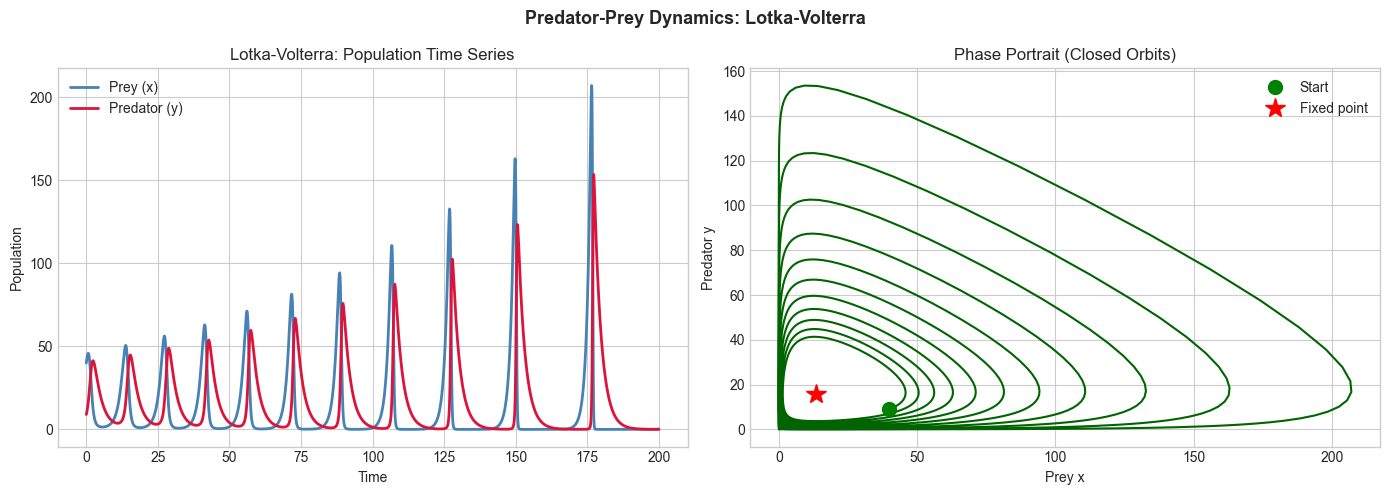

In [2]:
# Stage 1: Simulate the continuous Lotka-Volterra system
def lotka_volterra_euler(x0, y0, alpha, beta, delta, gamma, n_days=200, dt=0.05):
    xs, ys, ts = [x0], [y0], [0]
    x, y, t = float(x0), float(y0), 0
    while t < n_days:
        dx = (alpha * x - beta * x * y) * dt
        dy = (delta * x * y - gamma * y) * dt
        x = max(0, x + dx)
        y = max(0, y + dy)
        t += dt
        xs.append(x); ys.append(y); ts.append(t)
    return np.array(ts), np.array(xs), np.array(ys)

t, x, y = lotka_volterra_euler(40, 9, alpha, beta, delta, gamma)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t, x, color='steelblue', linewidth=2, label='Prey (x)')
axes[0].plot(t, y, color='crimson', linewidth=2, label='Predator (y)')
axes[0].set_title('Lotka-Volterra: Population Time Series')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Population'); axes[0].legend()

axes[1].plot(x, y, color='darkgreen', linewidth=1.5)
axes[1].plot(x[0], y[0], 'go', markersize=10, label='Start')
axes[1].plot(gamma/delta, alpha/beta, 'r*', markersize=15, label='Fixed point')
axes[1].set_title('Phase Portrait (Closed Orbits)')
axes[1].set_xlabel('Prey x'); axes[1].set_ylabel('Predator y'); axes[1].legend()

plt.suptitle('Predator-Prey Dynamics: Lotka-Volterra', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## 3. Stage 2 — Phase Portrait and Stability

Plot multiple orbits from different initial conditions to visualize the phase space structure.

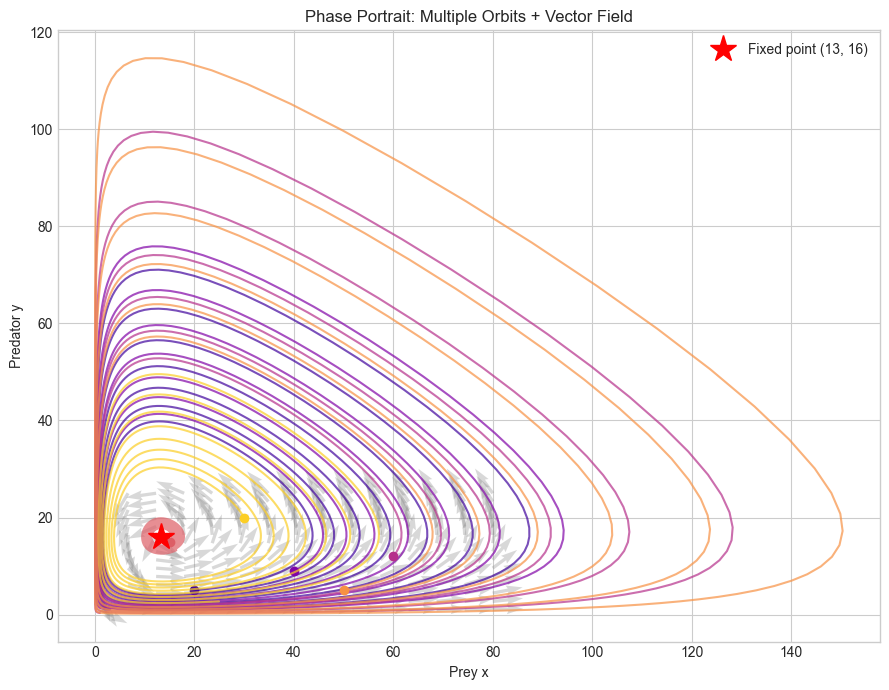

In [3]:
# Stage 2: Multiple orbits and fixed point analysis
fig, ax = plt.subplots(figsize=(9, 7))

# Plot vector field
x_grid = np.linspace(1, 80, 15)
y_grid = np.linspace(1, 25, 15)
X, Y = np.meshgrid(x_grid, y_grid)
dX = alpha * X - beta * X * Y
dY = delta * X * Y - gamma * Y
speed = np.sqrt(dX**2 + dY**2) + 1e-6
ax.quiver(X, Y, dX/speed, dY/speed, alpha=0.3, color='gray')

# Several initial conditions
colors = plt.cm.plasma(np.linspace(0.1, 0.9, 6))
for (x0, y0), color in zip([(20,5), (40,9), (60,12), (15,15), (50,5), (30,20)], colors):
    _, xo, yo = lotka_volterra_euler(x0, y0, alpha, beta, delta, gamma, n_days=100)
    ax.plot(xo, yo, color=color, linewidth=1.5, alpha=0.7)
    ax.plot(x0, y0, 'o', color=color, markersize=6)

# Fixed point
x_star, y_star = gamma/delta, alpha/beta
ax.plot(x_star, y_star, 'r*', markersize=20, zorder=5, label=f'Fixed point ({x_star:.0f}, {y_star:.0f})')
ax.set_title('Phase Portrait: Multiple Orbits + Vector Field')
ax.set_xlabel('Prey x'); ax.set_ylabel('Predator y'); ax.legend()
plt.tight_layout(); plt.show()

---

## 4. Stage 3 — Parameter Variation and Bifurcation

Vary the predation rate β and observe how the amplitude and period of oscillations change.

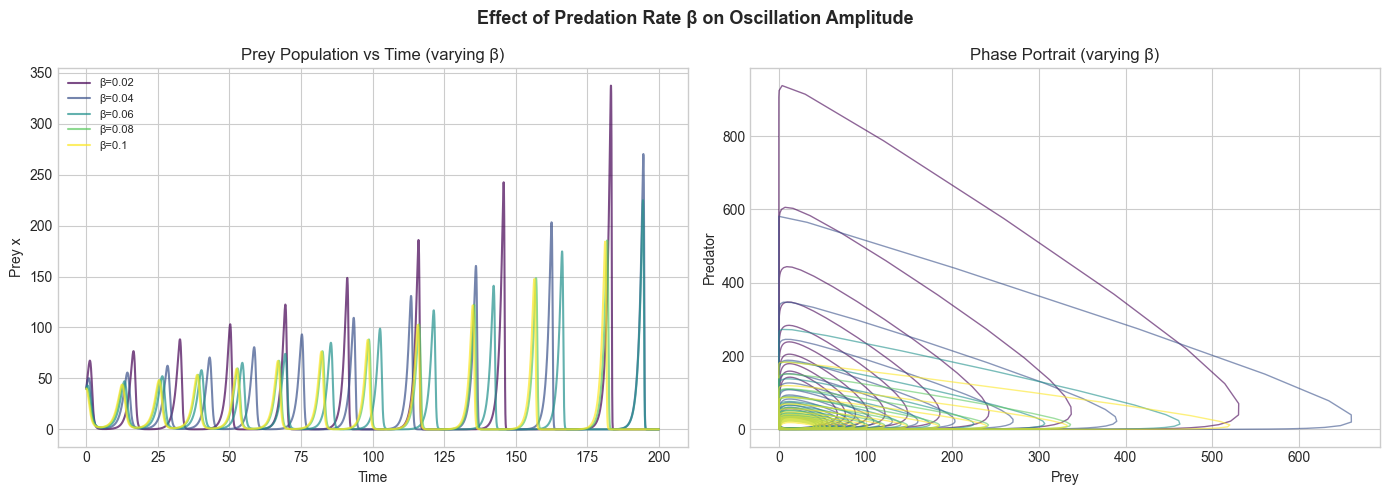

In [4]:
# Stage 3: Effect of varying predation rate
beta_values = [0.02, 0.04, 0.06, 0.08, 0.10]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bv, color in zip(beta_values, plt.cm.viridis(np.linspace(0,1,len(beta_values)))):
    t, x, y = lotka_volterra_euler(40, 9, alpha, bv, delta, gamma, n_days=300)
    axes[0].plot(t[:4000], x[:4000], color=color, linewidth=1.5, alpha=0.7, label=f'β={bv}')
    # Phase portrait
    axes[1].plot(x, y, color=color, linewidth=1, alpha=0.6)

axes[0].set_title('Prey Population vs Time (varying β)'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Prey x')
axes[1].set_title('Phase Portrait (varying β)'); axes[1].set_xlabel('Prey'); axes[1].set_ylabel('Predator')
plt.suptitle('Effect of Predation Rate β on Oscillation Amplitude', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## 5. Results & Reflection

**What was built:**
A full Lotka-Volterra predator-prey simulation with time series, phase portraits, vector fields, and parameter sensitivity.

**What math made it possible:**
- Discrete dynamical systems extended to continuous ODEs (ch076, ch078)
- Fixed point analysis: x* = γ/δ, y* = α/β
- Phase portraits visualize orbits in 2D state space
- Parameter sensitivity (ch069) reveals how β controls amplitude

**Extension challenges:**
1. Add environmental carrying capacity for prey: dx/dt = αx(1 - x/K) - βxy. How does K change the dynamics?
2. Add a third species (a super-predator). Simulate and observe whether the system stabilizes or oscillates more.
3. Implement a discrete-time version and compare its behavior to the continuous ODE.